# Model Training & Evaluation

**Goal:** Train classifiers that can flag a systemic crisis *one year in advance*,
starting from the simplest possible model and progressively adding smarter
imbalance-handling strategies.

This notebook covers:
1. **Baseline Logistic Regression** - no class-weight correction; exposes the recall
   problem caused by class imbalance.
2. **Balanced LR, Random Forest, XGBoost** - each adding one additional
   imbalance-handling layer.

> **All evaluation is on the validation set (2000-2009).** The test set (2010-2014)
> is untouched until the final notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, fbeta_score,
    average_precision_score, precision_recall_curve
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load Train & Validation Sets

In [2]:
train = pd.read_csv('../data/train.csv')
val   = pd.read_csv('../data/validation.csv')

print(f"Train : {train.shape[0]:>4} rows  |  years {train['year'].min()}-{train['year'].max()}")
print(f"Val   : {val.shape[0]:>4} rows  |  years {val['year'].min()}-{val['year'].max()}")

Train :  866 rows  |  years 1860-1999
Val   :  130 rows  |  years 2000-2009


## 2. Define Feature Matrix and Target

We use **only lagged and derived features** - no same-year raw values,
which would leak future information into training.

In [4]:
LAG_BASE_COLS = [
    'exch_usd_capped', 'inflation_capped',
    'domestic_debt_in_default', 'sovereign_external_debt_default',
    'gdp_weighted_default', 'currency_crises', 'inflation_crises', 'banking_crisis'
]

FEATURE_COLS = (
    [col + '_lag1' for col in LAG_BASE_COLS] +
    [col + '_lag2' for col in LAG_BASE_COLS] +
    ['exch_usd_pct_change', 'inflation_volatility', 'independence']
)
TARGET = 'crisis_next_year'

# Median imputation for any residual NaNs

# compute medians from TRAIN only to avoid leakage
train_median = train[FEATURE_COLS].median()

X_train = train[FEATURE_COLS].fillna(train_median)
y_train = train[TARGET].astype(int)

X_val = val[FEATURE_COLS].fillna(train_median)
y_val = val[TARGET].astype(int)

print(f"Features : {len(FEATURE_COLS)}")
print(f"Train    : {X_train.shape}  |  crisis rate = {y_train.mean():.1%}")
print(f"Val      : {X_val.shape}  |  crisis rate = {y_val.mean():.1%}")

Features : 19
Train    : (866, 19)  |  crisis rate = 7.6%
Val      : (130, 19)  |  crisis rate = 8.5%


## 3. Evaluation Helper

A single reusable function keeps all metrics consistent across every model
we build in this notebook.

In [12]:
def evaluate(y_true, y_pred, y_prob, model_name='Model'):
    """Compute and print classification metrics; return a summary dict."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'Model'     : model_name,
        'TP'        : int(tp),
        'FN'        : int(fn),
        'FP'        : int(fp),
        'TN'        : int(tn),
        'Precision' : round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall'    : round(recall_score(y_true, y_pred, zero_division=0), 3),
        'F1'        : round(f1_score(y_true, y_pred, zero_division=0), 3),
        'F2'        : round(fbeta_score(y_true, y_pred, beta=2, zero_division=0), 3),
        'PR-AUC'    : round(average_precision_score(y_true, y_prob), 3),
    }

    sep = '-' * 48
    print(f'\n{sep}')
    print(f'  {model_name}')
    print(sep)
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:<12} {v}')
    print(sep)
    return metrics

---
## 4. Baseline: Logistic Regression (no class weights)

Start with the simplest possible classifier:
**L2 Logistic Regression, default decision threshold = 0.5, no imbalance correction.**

The purpose of this baseline is to *quantify the damage* caused by ignoring the 7.6% crisis rate.
We expect high accuracy but near-zero recall - the model will learn to always predict 'no crisis'
because doing so minimises log-loss on an imbalanced dataset.

### 4.1 Feature Scaling

Logistic Regression is sensitive to feature magnitude.
We fit `StandardScaler` on training data only, then apply the same transformation to validation.
Fitting on validation data would constitute data leakage.

In [7]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print('Scaling done. Mean of first feature in train (should be 0):', X_train_sc[:, 0].mean().round(6))

Scaling done. Mean of first feature in train (should be 0): 0.0


### 4.2 Train

In [9]:
lr_baseline = LogisticRegression(
    C=1.0,
    class_weight=None,
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_baseline.fit(X_train_sc, y_train)
print('Model trained successfully.')

Model trained successfully.


### 4.3 Predict on Validation Set

In [10]:
y_pred_base = lr_baseline.predict(X_val_sc)
y_prob_base = lr_baseline.predict_proba(X_val_sc)[:, 1]

print(f"Predicted positives (crises flagged) : {y_pred_base.sum()}")
print(f"Actual positives in val set          : {y_val.sum()}")
print(f"\nMaximum predicted probability        : {y_prob_base.max():.3f}")
print(f"Median predicted probability         : {np.median(y_prob_base):.3f}")
print("\n-> The model assigns very low probabilities to all observations.")
print("   At threshold=0.5, almost nothing is flagged as a crisis.")

Predicted positives (crises flagged) : 1
Actual positives in val set          : 11

Maximum predicted probability        : 0.835
Median predicted probability         : 0.035

-> The model assigns very low probabilities to all observations.
   At threshold=0.5, almost nothing is flagged as a crisis.


### 4.4 Metrics

In [13]:
baseline_metrics = evaluate(
    y_val, y_pred_base, y_prob_base,
    model_name='LR Baseline (no weights)'
)


------------------------------------------------
  LR Baseline (no weights)
------------------------------------------------
  TP           0
  FN           11
  FP           1
  TN           118
  Precision    0.0
  Recall       0.0
  F1           0.0
  F2           0.0
  PR-AUC       0.086
------------------------------------------------


### 4.5 Confusion Matrix

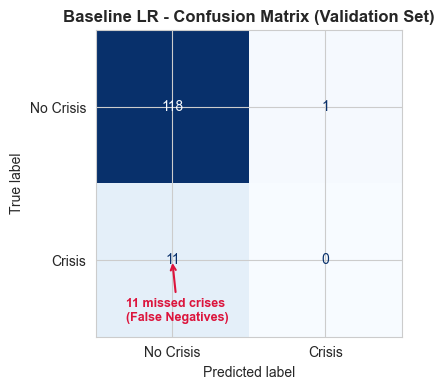

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_val, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Baseline LR - Confusion Matrix (Validation Set)',
             fontsize=12, fontweight='bold')

fn_count = cm[1, 0]
ax.annotate(
    f'{fn_count} missed crises\n(False Negatives)',
    xy=(0, 1), xycoords='data',
    fontsize=9, color='crimson', fontweight='bold',
    xytext=(-0.3, 1.4),
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5)
)

plt.tight_layout()
plt.show()

### 4.6  Confusion Matrix Result

| Quadrant | Count | Business meaning |
|---|---|---|
| True Negatives (TN) | 118 | Correctly identified calm years |
| False Positives (FP) | 1 | One false alarm - acceptable cost |
| **False Negatives (FN)** | **11** | **Crisis years the model completely missed** |
| True Positives (TP) | 0 | Zero crises correctly flagged |

> **The model has 92% accuracy but zero recall.**
> It has learned the trivial rule: *predict 'no crisis' every year.*

### 4.7 Precision-Recall Curve

The **Precision-Recall curve** focuses entirely on
the minority class (crises) and shows the precision/recall trade-off as we lower the
decision threshold from 1.0 down to 0.

A **no-skill classifier** that always predicts the majority class achieves
PR-AUC equal to the crisis base rate (7.6%). The model should do better - but
the baseline will sit embarrassingly close to this floor.

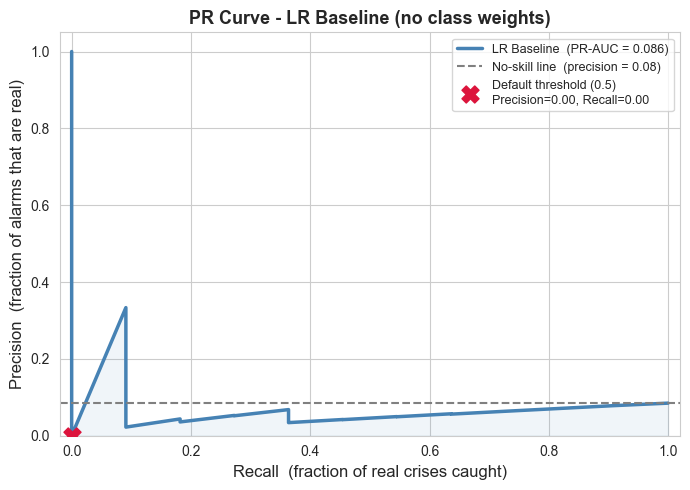

Baseline PR-AUC : 0.086
No-skill PR-AUC : 0.085  (= crisis rate in val set)


In [16]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_prob_base)

no_skill_level = y_val.mean()
prauc_baseline = average_precision_score(y_val, y_prob_base)

fig, ax = plt.subplots(figsize=(7, 5))

# PR curve for baseline model
ax.plot(recall_vals, precision_vals,
        color='steelblue', lw=2.5,
        label=f'LR Baseline  (PR-AUC = {prauc_baseline:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')

# No-skill horizontal baseline
ax.axhline(no_skill_level, color='grey', linestyle='--', lw=1.5,
           label=f'No-skill line  (precision = {no_skill_level:.2f})')

default_prec = precision_score(y_val, y_pred_base, zero_division=0)
default_rec  = recall_score(y_val, y_pred_base, zero_division=0)
ax.scatter([default_rec], [default_prec], s=150, zorder=5,
           color='crimson', marker='X',
           label=(
               f'Default threshold (0.5)\n'
               f'Precision={default_prec:.2f}, Recall={default_rec:.2f}'
           ))

ax.set_xlabel('Recall  (fraction of real crises caught)', fontsize=12)
ax.set_ylabel('Precision  (fraction of alarms that are real)', fontsize=12)
ax.set_title('PR Curve - LR Baseline (no class weights)', fontsize=13, fontweight='bold')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print(f'Baseline PR-AUC : {prauc_baseline:.3f}')
print(f'No-skill PR-AUC : {no_skill_level:.3f}  (= crisis rate in val set)')

The baseline is barely above the no-skill line, confirming that
the model provides almost no useful signal for detecting crises.

### 4.8 Distribution of Predicted Probabilities

To understand *why* recall is zero, we inspect what the model actually assigns
as crisis probabilities. Expected the distribution to be heavily right-skewed
- almost everything below 0.5.

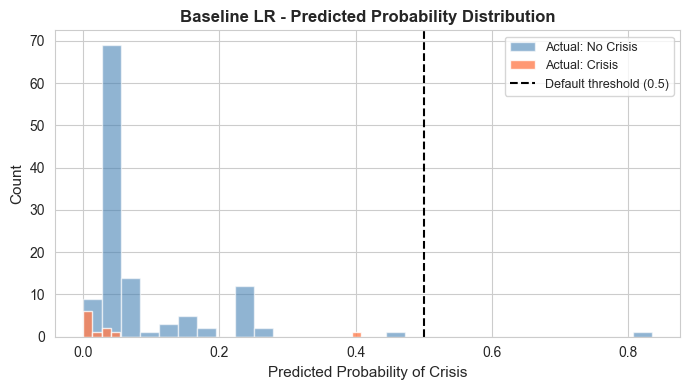

Crisis observations    | mean prob: 0.049 | max: 0.408
No-crisis observations | mean prob: 0.081 | max: 0.835


In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

prob_crisis    = y_prob_base[y_val == 1]
prob_no_crisis = y_prob_base[y_val == 0]

ax.hist(prob_no_crisis, bins=30, alpha=0.6, color='steelblue', label='Actual: No Crisis')
ax.hist(prob_crisis,    bins=30, alpha=0.8, color='coral',     label='Actual: Crisis')

ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Default threshold (0.5)')

ax.set_xlabel('Predicted Probability of Crisis', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Baseline LR - Predicted Probability Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Crisis observations    | mean prob: {prob_crisis.mean():.3f} | max: {prob_crisis.max():.3f}')
print(f'No-crisis observations | mean prob: {prob_no_crisis.mean():.3f} | max: {prob_no_crisis.max():.3f}')

Even for REAL crisis years, the model assigns probabilities well below 0.5.

---
### 4.9 Baseline Summary & Diagnosis

```
LR Baseline (no weights)
------------------------------------------------
  TP           0
  FN           11
  FP           1
  TN           118
  Precision    0.0
  Recall       0.0
  F1           0.0
  F2           0.0
  PR-AUC       0.086
------------------------------------------------
```

**Root cause:**
With 7.6% crisis years, minimising log-loss means the model assigns
low probabilities to the positive class across the board.
At the default threshold of 0.5, every observation is predicted 'no crisis'.

**Three complementary fixes - applied in the next sections:**

| Fix | Mechanism | Applied to |
|---|---|---|
| `class_weight='balanced'` | Upweights crisis examples in the loss | Logistic Regression |
| SMOTE | Synthesises new minority-class samples | Logistic Regression |
| `scale_pos_weight` | Equivalent upweighting in gradient boosting | XGBoost |
